# Spotify Playlist Analysis

Initial exploratory data analysis for the playlist dataset.

This notebook is organized into explicit steps so it is easy to follow the workflow from raw data to cleaned data to first-pass descriptive analysis.


## 1. Setup

Import libraries, set display options, and define small helper functions used later in the notebook.


In [66]:
import ast
from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# Show all columns when inspecting DataFrames.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Set a consistent plotting style for all charts.
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

def make_hashable(value):
    """Convert list-like values so nunique works on object columns such as tokens."""
    if isinstance(value, list):
        return tuple(value)
    return value


## 2. Load Raw Data

Read the tab-separated input file and inspect the basic shape of the dataset before making any changes.


In [67]:
# Load the raw playlist dataset.
df = pd.read_csv('playlist_revision_v05.txt', sep='\t')

print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
display(df.head())


Rows: 427,276
Columns: 29


,playlist_uri,owner,streams,stream30s,dau,wau,mau,mau_previous_month,mau_both_months,users,skippers,owner_country,n_tracks,n_local_tracks,n_artists,n_albums,monthly_stream30s,monthly_owner_stream30s,tokens,genre_1,genre_2,genre_3,mood_1,mood_2,mood_3,premium_mau_previous_month,premium_mau,mau_premium_ratio,mau_previous_month_premium_ratio
0,spotify:user:25d04611ade7d93b279098dd90c2dcde:playlist:38119f5d55b3320109b617,25d04611ade7d93b279098dd90c2dcde,0,0,0,2,3,1,1,3,0,US,44,18,20,19,64,6,"[""eclectronic""]",Electronica,Alternative,Dance & House,Sensual,Excited,Brooding,1.00,1.00,NaN,NaN
1,spotify:user:a99297eb43f794a785a32258cc5320e7:playlist:4b1cefbd7a3e3a68bcb7bb,a99297eb43f794a785a32258cc5320e7,0,0,0,0,2,0,0,2,0,US,249,0,79,81,31,26,"[""party"", ""woodside""]",Pop,Latin,Rap,Excited,Energizing,Defiant,0.00,2.00,NaN,NaN
2,spotify:user:294f08499afea11c56ddf92ab3ce6f56:playlist:ddb53de2253ec62f262d08,294f08499afea11c56ddf92ab3ce6f56,5,5,1,3,5,3,1,9,0,US,313,0,271,257,682,617,"[""five"", ""hours""]",Alternative,Electronica,Pop,Excited,Aggressive,Urgent,2.00,3.00,NaN,NaN
3,spotify:user:acfea3b5d4a4b8fefa6c8605738788e8:playlist:1dad98bc22d2791f926499,acfea3b5d4a4b8fefa6c8605738788e8,30,30,1,1,2,2,1,3,0,US,109,13,90,94,49,5,"[""summertime""]",Alternative,Rap,Pop,Defiant,Excited,Energizing,2.00,2.00,NaN,NaN
4,spotify:user:46f8f6c970f7a68ec67fe69514e9b182:playlist:8a7d9fdf758faadba2a1a6,46f8f6c970f7a68ec67fe69514e9b182,0,0,0,1,2,2,1,6,0,US,414,0,284,24,15,9,"[""latino"", ""greatest"", ""hits""]",Pop,R&B,Blues,Energizing,Lively,Fiery,2.00,1.00,NaN,NaN


## 3. Data Cleaning

Create a cleaned version of the data while keeping the raw `df` available for reference.

Cleaning choices in this notebook:
- Drop columns that are constant or effectively unusable.
- Remove exact duplicate rows.
- Convert `'-'` placeholders in genre and mood columns to missing values.
- Parse `tokens` from a string representation into a real Python list.
- Extract `uri_owner` and `playlist_id` from `playlist_uri`.
- Create an `is_spotify_owned` flag for playlists where the owner is literally `spotify`.
- Create an `owner_playlist_count` feature to count how many playlists each owner has in the cleaned dataset.
- Leave the optional `stream30s <= streams` fix commented out for now.


In [68]:
# Start from a copy so the raw DataFrame remains unchanged.
df_clean = df.copy()

# These columns are non-informative for analysis in this dataset.
drop_cols = [
    'owner_country',
    'mau_premium_ratio',
    'mau_previous_month_premium_ratio'
]

# In the genre and mood columns, '-' appears to mean missing rather than a real category.
dash_cols = ['genre_1', 'genre_2', 'genre_3', 'mood_1', 'mood_2', 'mood_3']

# Capture a few counts before mutating the data so the cleaning step is easy to summarize.
duplicate_rows = int(df_clean.duplicated().sum())
dash_placeholder_count = int((df_clean[dash_cols] == '-').sum().sum())

# Apply the main cleaning operations.
df_clean = df_clean.drop(columns=drop_cols).drop_duplicates()
df_clean[dash_cols] = df_clean[dash_cols].replace('-', np.nan)
df_clean['tokens'] = df_clean['tokens'].apply(ast.literal_eval)

# Parse the playlist URI into separate components that may be useful later.
uri_parts = df_clean['playlist_uri'].str.split(':', expand=True)
df_clean['uri_owner'] = uri_parts[2]
df_clean['playlist_id'] = uri_parts[4]

# Flag playlists owned by the platform account itself.
df_clean['is_spotify_owned'] = df_clean['owner'].eq('spotify')

# Count how many playlists each owner has in the cleaned dataset.
df_clean['owner_playlist_count'] = df_clean.groupby('owner')['playlist_uri'].transform('count')

# Optional data-quality fix if we later decide to enforce stream30s <= streams.
# df_clean['stream30s'] = np.minimum(df_clean['stream30s'], df_clean['streams'])

print(f'Rows: {df.shape[0]:,} -> {df_clean.shape[0]:,}')
print(f'Columns: {df.shape[1]} -> {df_clean.shape[1]}')
print(f'Exact duplicate rows removed: {duplicate_rows:,}')
print(f'Dash placeholders converted to missing: {dash_placeholder_count:,}')
print(f'Columns dropped: {drop_cols}')
print(f"Spotify-owned playlists: {df_clean['is_spotify_owned'].sum():,}")
display(df_clean.head())


Rows: 427,276 -> 417,484
Columns: 29 -> 30
Exact duplicate rows removed: 9,792
Dash placeholders converted to missing: 127,410
Columns dropped: ['owner_country', 'mau_premium_ratio', 'mau_previous_month_premium_ratio']
Spotify-owned playlists: 399


,playlist_uri,owner,streams,stream30s,dau,wau,mau,mau_previous_month,mau_both_months,users,skippers,n_tracks,n_local_tracks,n_artists,n_albums,monthly_stream30s,monthly_owner_stream30s,tokens,genre_1,genre_2,genre_3,mood_1,mood_2,mood_3,premium_mau_previous_month,premium_mau,uri_owner,playlist_id,is_spotify_owned,owner_playlist_count
0,spotify:user:25d04611ade7d93b279098dd90c2dcde:playlist:38119f5d55b3320109b617,25d04611ade7d93b279098dd90c2dcde,0,0,0,2,3,1,1,3,0,44,18,20,19,64,6,[eclectronic],Electronica,Alternative,Dance & House,Sensual,Excited,Brooding,1.00,1.00,25d04611ade7d93b279098dd90c2dcde,38119f5d55b3320109b617,False,2
1,spotify:user:a99297eb43f794a785a32258cc5320e7:playlist:4b1cefbd7a3e3a68bcb7bb,a99297eb43f794a785a32258cc5320e7,0,0,0,0,2,0,0,2,0,249,0,79,81,31,26,"[party, woodside]",Pop,Latin,Rap,Excited,Energizing,Defiant,0.00,2.00,a99297eb43f794a785a32258cc5320e7,4b1cefbd7a3e3a68bcb7bb,False,1
2,spotify:user:294f08499afea11c56ddf92ab3ce6f56:playlist:ddb53de2253ec62f262d08,294f08499afea11c56ddf92ab3ce6f56,5,5,1,3,5,3,1,9,0,313,0,271,257,682,617,"[five, hours]",Alternative,Electronica,Pop,Excited,Aggressive,Urgent,2.00,3.00,294f08499afea11c56ddf92ab3ce6f56,ddb53de2253ec62f262d08,False,2
3,spotify:user:acfea3b5d4a4b8fefa6c8605738788e8:playlist:1dad98bc22d2791f926499,acfea3b5d4a4b8fefa6c8605738788e8,30,30,1,1,2,2,1,3,0,109,13,90,94,49,5,[summertime],Alternative,Rap,Pop,Defiant,Excited,Energizing,2.00,2.00,acfea3b5d4a4b8fefa6c8605738788e8,1dad98bc22d2791f926499,False,2
4,spotify:user:46f8f6c970f7a68ec67fe69514e9b182:playlist:8a7d9fdf758faadba2a1a6,46f8f6c970f7a68ec67fe69514e9b182,0,0,0,1,2,2,1,6,0,414,0,284,24,15,9,"[latino, greatest, hits]",Pop,R&B,Blues,Energizing,Lively,Fiery,2.00,1.00,46f8f6c970f7a68ec67fe69514e9b182,8a7d9fdf758faadba2a1a6,False,1


## 4. Column-Level Overview

Summarize each column's type, missingness, and cardinality after cleaning. This helps identify remaining sparse columns, ID-like fields, and high-cardinality variables.


In [69]:
# Split columns into numeric and non-numeric groups for later EDA steps.
numeric_cols = df_clean.select_dtypes(include='number').columns.tolist()
categorical_cols = df_clean.select_dtypes(exclude='number').columns.tolist()

# Build a compact per-column summary table.
column_summary = pd.DataFrame({
    'dtype': df_clean.dtypes.astype(str),
    'non_null_count': df_clean.notna().sum(),
    'null_count': df_clean.isna().sum(),
    'null_pct': df_clean.isna().mean().mul(100),
    'n_unique': df_clean.apply(lambda s: s.map(make_hashable).nunique(dropna=False))
}).sort_values(['null_pct', 'n_unique'], ascending=[False, False])

display(column_summary)


,dtype,non_null_count,null_count,null_pct,n_unique
genre_3,object,363243,54241,12.99,26
genre_2,object,382161,35323,8.46,26
mood_3,object,401362,16122,3.86,27
mood_2,object,401499,15985,3.83,27
mood_1,object,415638,1846,0.44,27
genre_1,object,416502,982,0.24,26
premium_mau_previous_month,float64,417483,1,0.00,1362
premium_mau,float64,417483,1,0.00,1286
playlist_uri,object,417484,0,0.00,417484
playlist_id,object,417484,0,0.00,417484


## 5. Spotify-Owned Playlist Segment

Inspect the subset of playlists where `owner == 'spotify'`. These are a very small share of playlists, but they appear to behave very differently from the rest of the dataset.


In [70]:
# Split the cleaned data into Spotify-owned playlists and all other playlists.
spotify_df = df_clean[df_clean['is_spotify_owned']].copy()
other_df = df_clean[~df_clean['is_spotify_owned']].copy()

# Create a few derived metrics that help describe how this segment behaves.
spotify_df['owner_stream_share'] = spotify_df['monthly_owner_stream30s'] / spotify_df['monthly_stream30s'].replace(0, np.nan)
other_df['owner_stream_share'] = other_df['monthly_owner_stream30s'] / other_df['monthly_stream30s'].replace(0, np.nan)

spotify_df['non_owner_monthly_stream30s'] = (
    spotify_df['monthly_stream30s'] - spotify_df['monthly_owner_stream30s']
).clip(lower=0)
other_df['non_owner_monthly_stream30s'] = (
    other_df['monthly_stream30s'] - other_df['monthly_owner_stream30s']
).clip(lower=0)

spotify_df['retention_rate'] = spotify_df['mau_both_months'] / spotify_df['mau_previous_month'].replace(0, np.nan)
other_df['retention_rate'] = other_df['mau_both_months'] / other_df['mau_previous_month'].replace(0, np.nan)

print(f"Spotify-owned playlists: {len(spotify_df):,}")
print(f"Other playlists: {len(other_df):,}")
print(f"Share of cleaned dataset: {len(spotify_df) / len(df_clean) * 100:.3f}%")

segment_compare_cols = [
    'streams', 'stream30s', 'dau', 'wau', 'mau', 'mau_previous_month',
    'mau_both_months', 'users', 'skippers', 'n_tracks', 'n_local_tracks',
    'n_artists', 'n_albums', 'monthly_stream30s', 'monthly_owner_stream30s',
    'owner_stream_share', 'non_owner_monthly_stream30s', 'retention_rate'
]

# Compare the Spotify-owned segment with the rest of the dataset using means, medians, and upper-tail values.
segment_summary = []
for col in segment_compare_cols:
    segment_summary.append({
        'metric': col,
        'spotify_mean': spotify_df[col].mean(),
        'other_mean': other_df[col].mean(),
        'spotify_median': spotify_df[col].median(),
        'other_median': other_df[col].median(),
        'spotify_p90': spotify_df[col].quantile(0.90),
        'other_p90': other_df[col].quantile(0.90)
    })

segment_summary = pd.DataFrame(segment_summary)
display(segment_summary)


Spotify-owned playlists: 399
Other playlists: 417,085
Share of cleaned dataset: 0.096%


,metric,spotify_mean,other_mean,spotify_median,other_median,spotify_p90,other_p90
0,streams,"50,613.37",23.73,"6,794.00",1.00,"111,259.60",39.00
1,stream30s,"31,191.87",14.54,"4,602.00",0.00,"69,645.00",24.00
2,dau,"3,221.94",1.21,583.00,0.00,"8,183.60",1.00
3,wau,"16,695.06",5.11,"3,731.00",1.00,"43,201.40",3.00
4,mau,"51,858.42",14.39,"13,059.00",2.00,"130,304.60",9.00
5,mau_previous_month,"45,209.10",13.03,"10,741.00",2.00,"114,221.80",8.00
6,mau_both_months,"10,019.18",2.93,"1,383.00",1.00,"22,671.80",2.00
7,users,"117,791.80",31.75,"31,699.00",3.00,"299,656.20",21.00
8,skippers,"2,122.81",0.70,462.00,0.00,"5,738.40",1.00
9,n_tracks,85.32,194.90,59.00,80.00,173.00,407.00


In [71]:
# Describe the thematic makeup of Spotify-owned playlists.
spotify_genre_share = spotify_df['genre_1'].value_counts(normalize=True).mul(100).head(10).rename('share_pct')
spotify_mood_share = spotify_df['mood_1'].value_counts(normalize=True).mul(100).head(10).rename('share_pct')

# Flatten token lists so we can see the most common words in Spotify-owned playlist names.
spotify_token_counts = Counter(token for tokens in spotify_df['tokens'] for token in tokens)
spotify_top_tokens = pd.DataFrame(spotify_token_counts.most_common(15), columns=['token', 'count'])

display(spotify_genre_share.to_frame().round(2))
display(spotify_mood_share.to_frame().round(2))
display(spotify_top_tokens)


,share_pct
genre_1,
Indie Rock,21.80
Pop,17.04
Religious,11.28
Alternative,8.02
Electronica,7.27
Dance & House,6.27
Rock,5.01
Latin,4.76
Rap,4.51


,share_pct
mood_1,
Excited,15.29
Sensual,12.28
Yearning,9.27
Defiant,7.77
Brooding,6.77
Empowering,6.52
Urgent,5.51
Melancholy,4.76
Gritty,4.26


,token,count
0,indie,18
1,party,17
2,rock,15
3,folk,14
4,pop,14
5,country,13
6,chill,12
7,tracks,12
8,spotify,11
9,top,11


## 6. Owner-Level Concentration

Group playlists by `owner` to see whether most users create only one playlist or whether playlist creation is concentrated among a smaller group of heavy creators.


In [72]:
# Summarize owner-level activity and aggregate performance.
owner_summary = (
    df_clean.groupby('owner')
    .agg(
        playlist_count=('playlist_uri', 'count'),
        total_monthly_stream30s=('monthly_stream30s', 'sum'),
        median_monthly_stream30s=('monthly_stream30s', 'median'),
        total_mau=('mau', 'sum'),
        spotify_owned=('is_spotify_owned', 'max')
    )
    .sort_values(['playlist_count', 'total_monthly_stream30s'], ascending=[False, False])
)

print(f"Unique owners: {len(owner_summary):,}")
print(f"Median playlists per owner: {owner_summary['playlist_count'].median():.1f}")
print(f"Mean playlists per owner: {owner_summary['playlist_count'].mean():.3f}")
print(f"90th percentile of playlists per owner: {owner_summary['playlist_count'].quantile(0.90):.1f}")
print(f"95th percentile of playlists per owner: {owner_summary['playlist_count'].quantile(0.95):.1f}")
print(f"99th percentile of playlists per owner: {owner_summary['playlist_count'].quantile(0.99):.1f}")
print(f"Maximum playlists by a single owner: {owner_summary['playlist_count'].max():,}")

for k in [2, 3, 5, 10, 25, 50, 100]:
    owner_count = int((owner_summary['playlist_count'] >= k).sum())
    print(f'Owners with at least {k} playlists: {owner_count:,}')

display(owner_summary.head(20))


Unique owners: 329,017
Median playlists per owner: 1.0
Mean playlists per owner: 1.269
90th percentile of playlists per owner: 2.0
95th percentile of playlists per owner: 3.0
99th percentile of playlists per owner: 5.0
Maximum playlists by a single owner: 399
Owners with at least 2 playlists: 53,859
Owners with at least 3 playlists: 17,113
Owners with at least 5 playlists: 3,539
Owners with at least 10 playlists: 390
Owners with at least 25 playlists: 19
Owners with at least 50 playlists: 1
Owners with at least 100 playlists: 1


,playlist_count,total_monthly_stream30s,median_monthly_stream30s,total_mau,spotify_owned
owner,,,,,
spotify,399,365656216,"154,812.00",20691509,True
6987037f34b5cee787a1a5e8de9b2689,48,3199034,"2,661.00",182490,False
a5add6d0d5fbebb01abb2fbe7e47208d,47,59729,34.00,3921,False
f54f32d1c706754a70f8392aa1dbad46,44,287,6.00,241,False
4a03268bef1505a49f8b3eced879f311,43,36356,65.00,2817,False
17d6159195b25d619e0eff98f809c90e,40,9321,94.00,692,False
0467e18af314d5c84e3e92f196fb05b9,40,1350,18.00,156,False
9ff1b837bb1262d44f2194549748385a,40,1240,13.50,162,False
2682cc9acee40aa2d9098555fd0f2671,37,3621,60.00,417,False


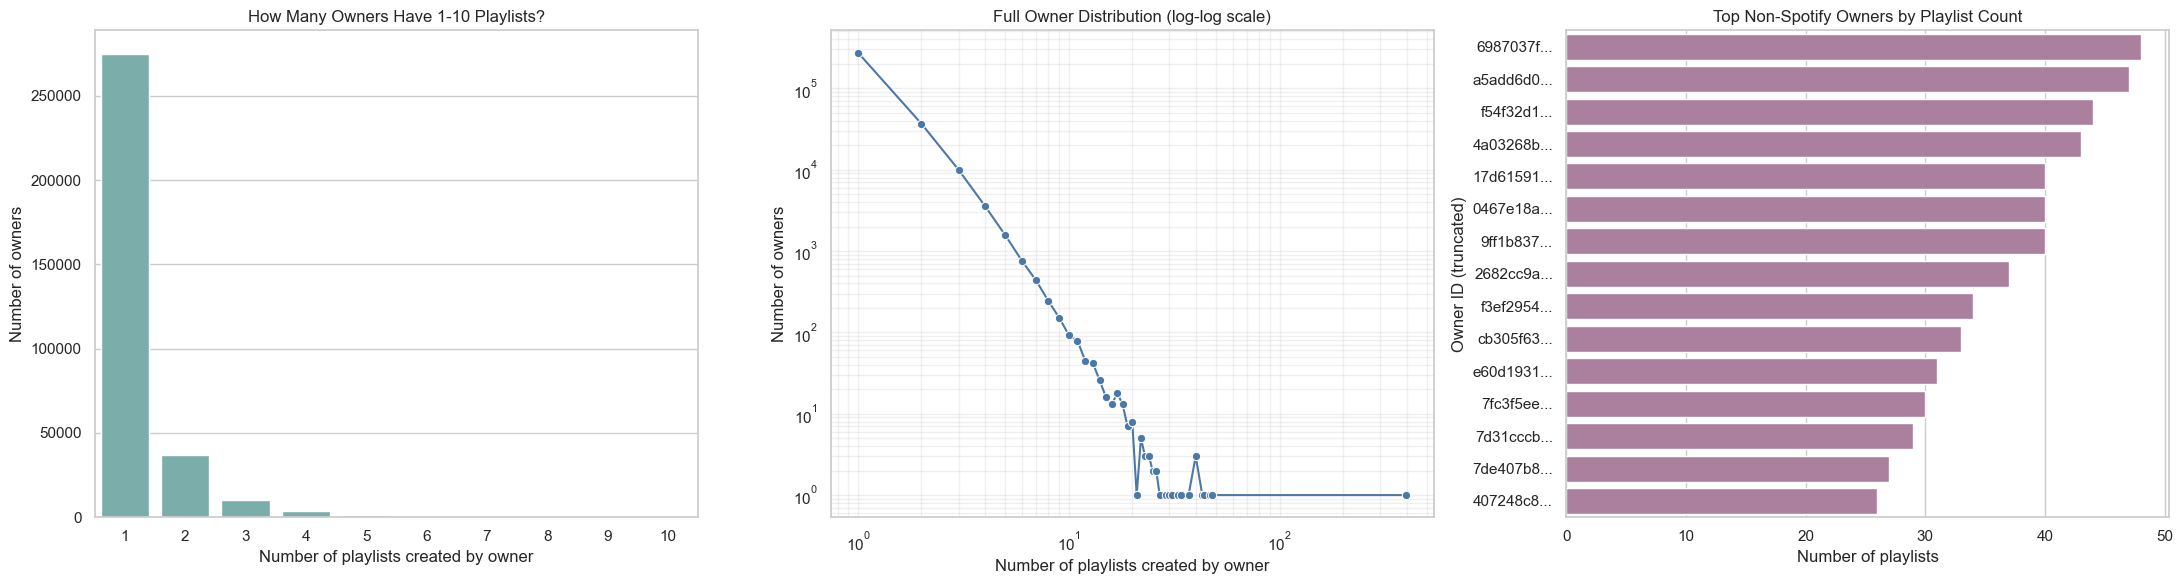

In [73]:
# Show the owner-playlist distribution at two different resolutions and the biggest non-Spotify owners.
owner_count_distribution = (
    owner_summary['playlist_count']
    .value_counts()
    .sort_index()
    .rename_axis('playlist_count')
    .reset_index(name='owner_count')
)

owner_count_distribution_small = owner_count_distribution[owner_count_distribution['playlist_count'] <= 10]

top_non_spotify_owners = owner_summary[~owner_summary['spotify_owned']].head(15).reset_index()
top_non_spotify_owners['owner_label'] = top_non_spotify_owners['owner'].str[:8] + '...'

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(data=owner_count_distribution_small, x='playlist_count', y='owner_count', color='#72B7B2', ax=axes[0])
axes[0].set_title('How Many Owners Have 1-10 Playlists?')
axes[0].set_xlabel('Number of playlists created by owner')
axes[0].set_ylabel('Number of owners')

# The full distribution is highly concentrated near 1 playlist per owner, so use log scales.
sns.lineplot(data=owner_count_distribution, x='playlist_count', y='owner_count', marker='o', color='#4C78A8', ax=axes[1])
axes[1].set_title('Full Owner Distribution (log-log scale)')
axes[1].set_xlabel('Number of playlists created by owner')
axes[1].set_ylabel('Number of owners')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, which='both', alpha=0.3)

sns.barplot(data=top_non_spotify_owners, x='playlist_count', y='owner_label', color='#B279A2', ax=axes[2])
axes[2].set_title('Top Non-Spotify Owners by Playlist Count')
axes[2].set_xlabel('Number of playlists')
axes[2].set_ylabel('Owner ID (truncated)')

plt.tight_layout()


## 7. Numeric Summary Statistics

Look at descriptive statistics for all numeric columns, including tail-focused percentiles to understand how skewed the dataset is.


In [74]:
# Include extra percentiles because many playlist metrics are highly skewed.
numeric_summary = df_clean[numeric_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

display(numeric_summary)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
streams,"417,484.00",72.08,"6,381.30",0.00,0.00,0.00,0.00,1.00,10.00,84.00,177.00,"2,629,715.00"
stream30s,"417,484.00",44.34,"3,708.09",0.00,0.00,0.00,0.00,0.00,6.00,60.00,130.00,"1,513,237.00"
dau,"417,484.00",4.29,352.74,0.00,0.00,0.00,0.00,0.00,1.00,2.00,8.00,"152,929.00"
wau,"417,484.00",21.06,"1,587.12",0.00,0.00,0.00,1.00,1.00,2.00,7.00,42.00,"669,966.00"
mau,"417,484.00",63.94,"4,651.89",1.00,1.00,2.00,2.00,2.00,3.00,20.00,137.00,"1,944,150.00"
mau_previous_month,"417,484.00",56.22,"3,761.99",0.00,0.00,0.00,1.00,2.00,3.00,19.00,125.00,"1,478,684.00"
mau_both_months,"417,484.00",12.50,"1,219.75",0.00,0.00,0.00,1.00,1.00,2.00,3.00,18.00,"578,391.00"
users,"417,484.00",144.29,"9,089.82",1.00,1.00,2.00,2.00,3.00,7.00,49.00,316.00,"3,455,406.00"
skippers,"417,484.00",2.73,201.56,0.00,0.00,0.00,0.00,0.00,0.00,1.00,5.00,"86,162.00"
n_tracks,"417,484.00",194.79,575.23,1.00,2.00,9.00,34.00,80.00,185.00,668.00,"1,832.17","79,984.00"


## 8. Distribution Diagnostics

Complement the standard summary table with a view that emphasizes zero-inflation and upper-tail behavior.


In [75]:
# This table is useful for spotting variables with many zeros and very large outliers.
distribution_summary = pd.DataFrame({
    'zero_pct': (df_clean[numeric_cols] == 0).mean().mul(100),
    'p50': df_clean[numeric_cols].median(),
    'p90': df_clean[numeric_cols].quantile(0.90),
    'p99': df_clean[numeric_cols].quantile(0.99),
    'max': df_clean[numeric_cols].max()
}).sort_values('p99', ascending=False)

display(distribution_summary)


,zero_pct,p50,p90,p99,max
monthly_stream30s,0.00,83.00,562.00,"2,734.17","42,497,334.00"
n_tracks,0.00,80.00,407.00,"1,832.17","79,984.00"
monthly_owner_stream30s,8.08,32.00,305.00,"1,013.00","25,904.00"
n_albums,0.00,46.00,201.00,607.00,"6,397.00"
n_artists,0.00,44.00,191.00,579.00,"5,226.00"
users,0.00,3.00,22.00,316.00,"3,455,406.00"
streams,47.20,1.00,39.00,177.00,"2,629,715.00"
mau,0.00,2.00,9.00,137.00,"1,944,150.00"
stream30s,50.94,0.00,24.00,130.00,"1,513,237.00"
mau_previous_month,12.43,2.00,8.00,125.00,"1,478,684.00"


## 9. Raw-Scale Distributions

Plot histograms for the main numeric variables. Each plot is capped at the 99th percentile so the long tail does not flatten the entire chart.


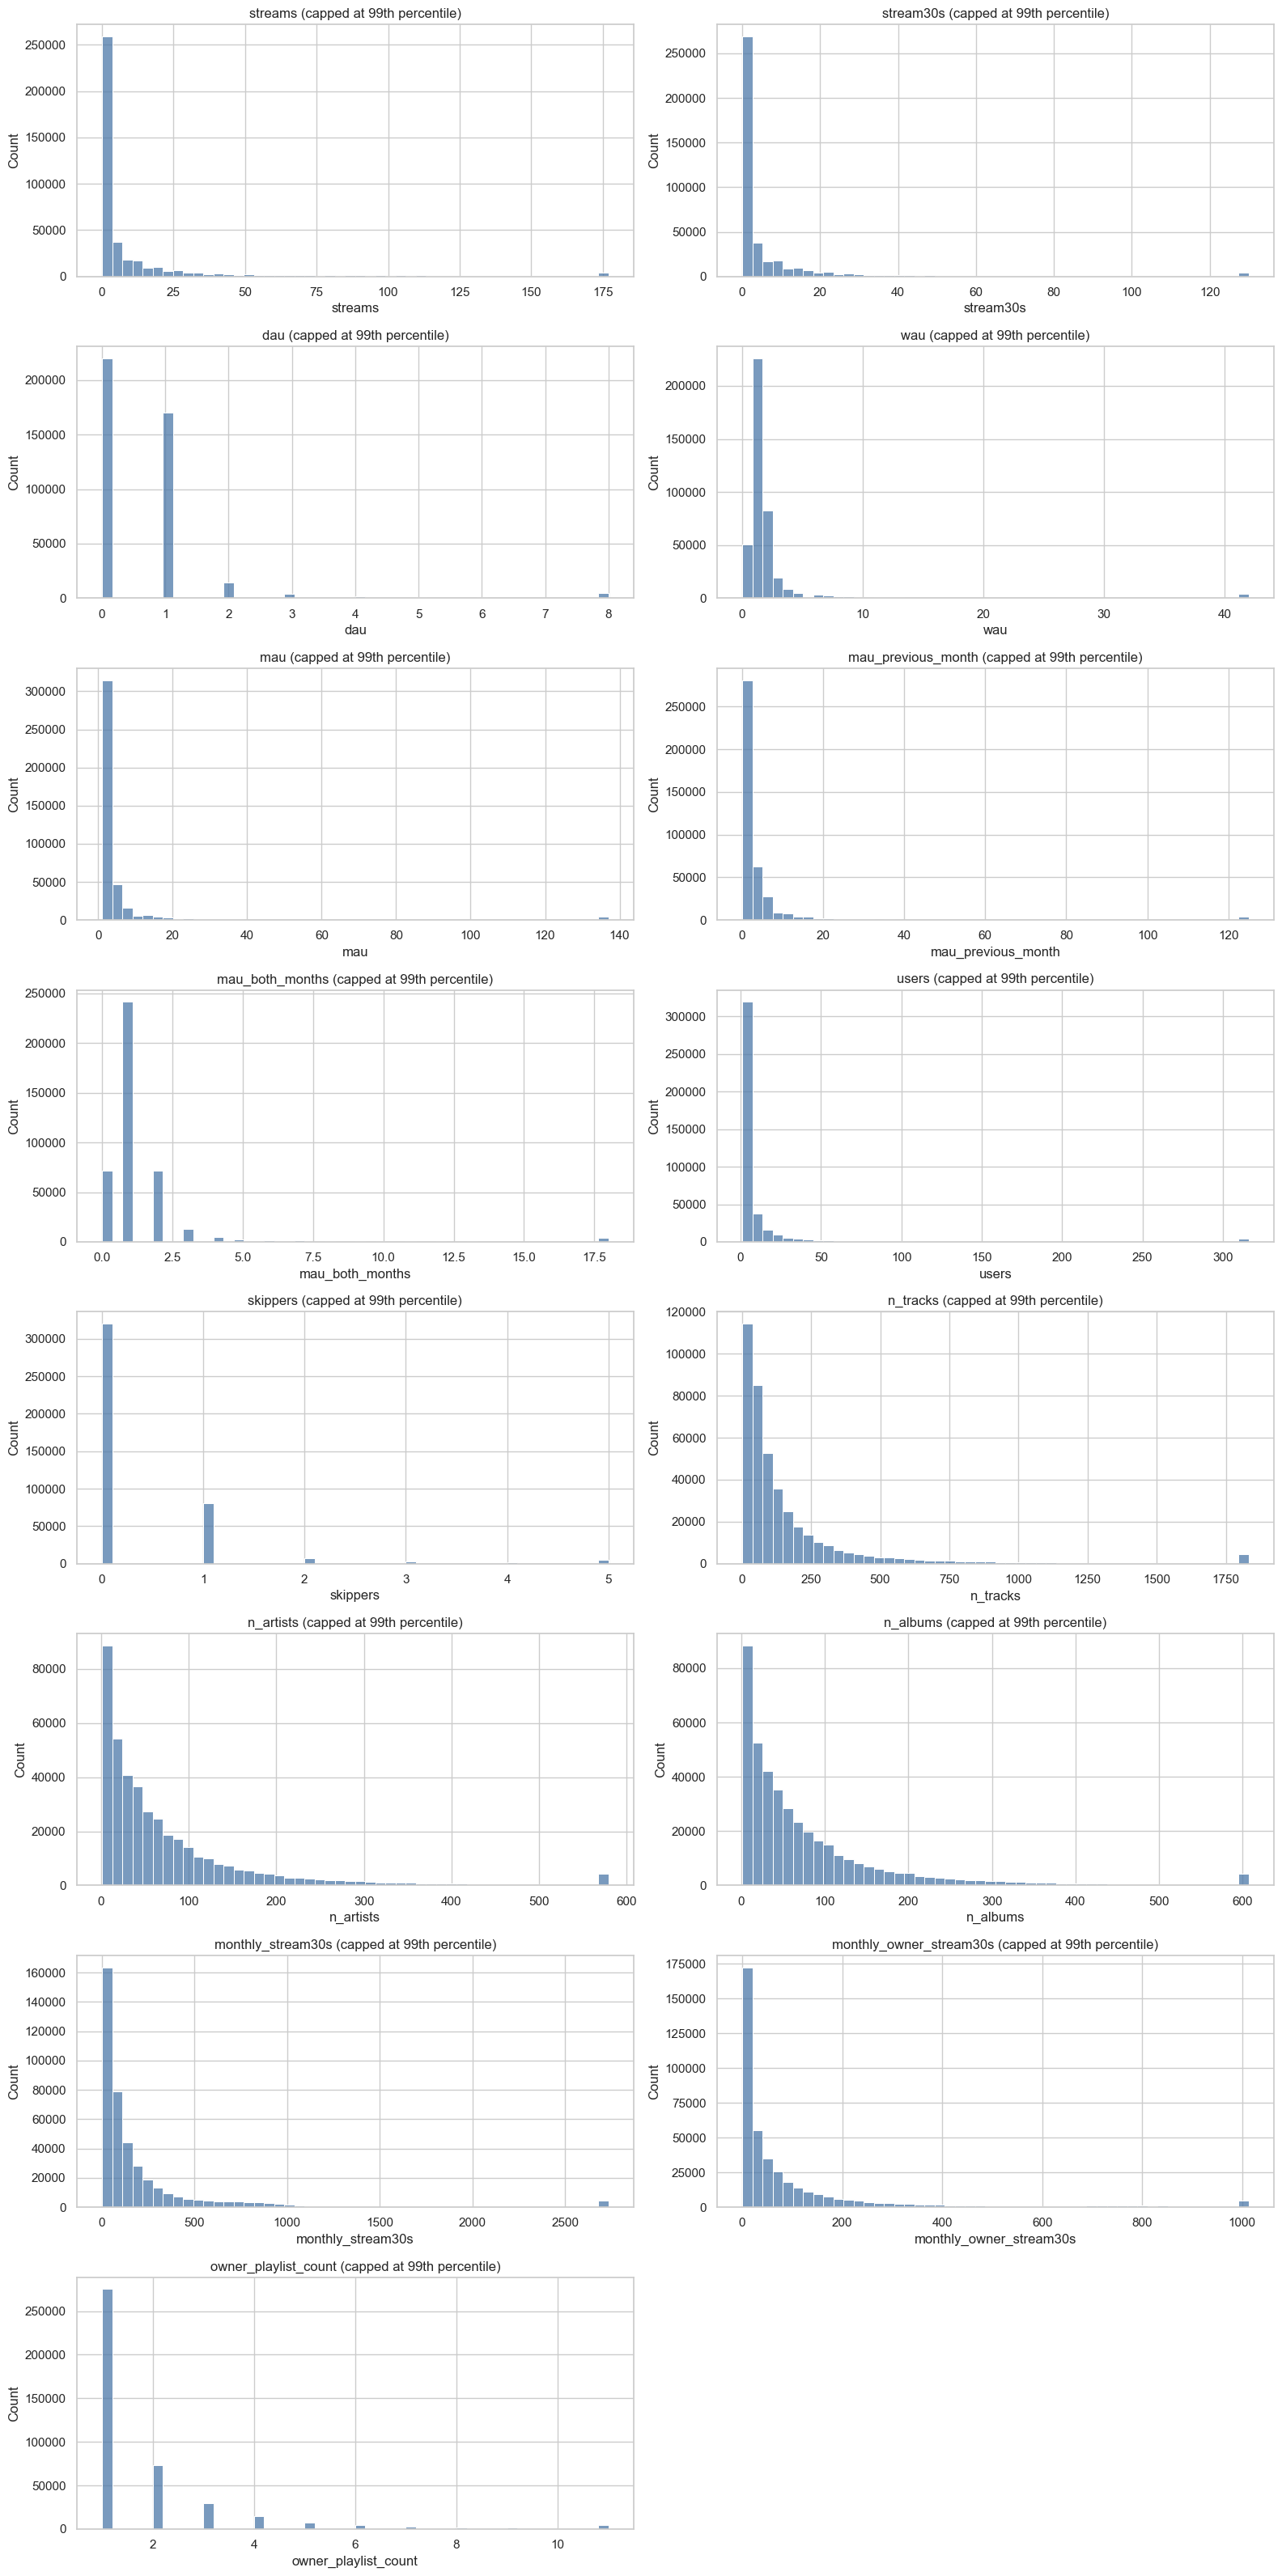

In [76]:
# Focus on a core set of playlist size and engagement columns.
plot_cols = [
    'streams', 'stream30s', 'dau', 'wau', 'mau', 'mau_previous_month',
    'mau_both_months', 'users', 'skippers', 'n_tracks', 'n_artists', 'n_albums',
    'monthly_stream30s', 'monthly_owner_stream30s', 'owner_playlist_count'
]

n_cols = 2
n_rows = int(np.ceil(len(plot_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    # Cap the display range, but do not change the underlying data.
    upper = df_clean[col].quantile(0.99)
    sns.histplot(df_clean[col].clip(upper=upper), bins=50, ax=ax, color='#4C78A8')
    ax.set_title(f'{col} (capped at 99th percentile)')
    ax.set_xlabel(col)

for ax in axes[len(plot_cols):]:
    ax.set_visible(False)

plt.tight_layout()


## 10. Log-Scale Distributions

Plot the same numeric variables on a `log1p` scale. This is especially helpful because many playlist metrics are heavily right-skewed and include zeros.


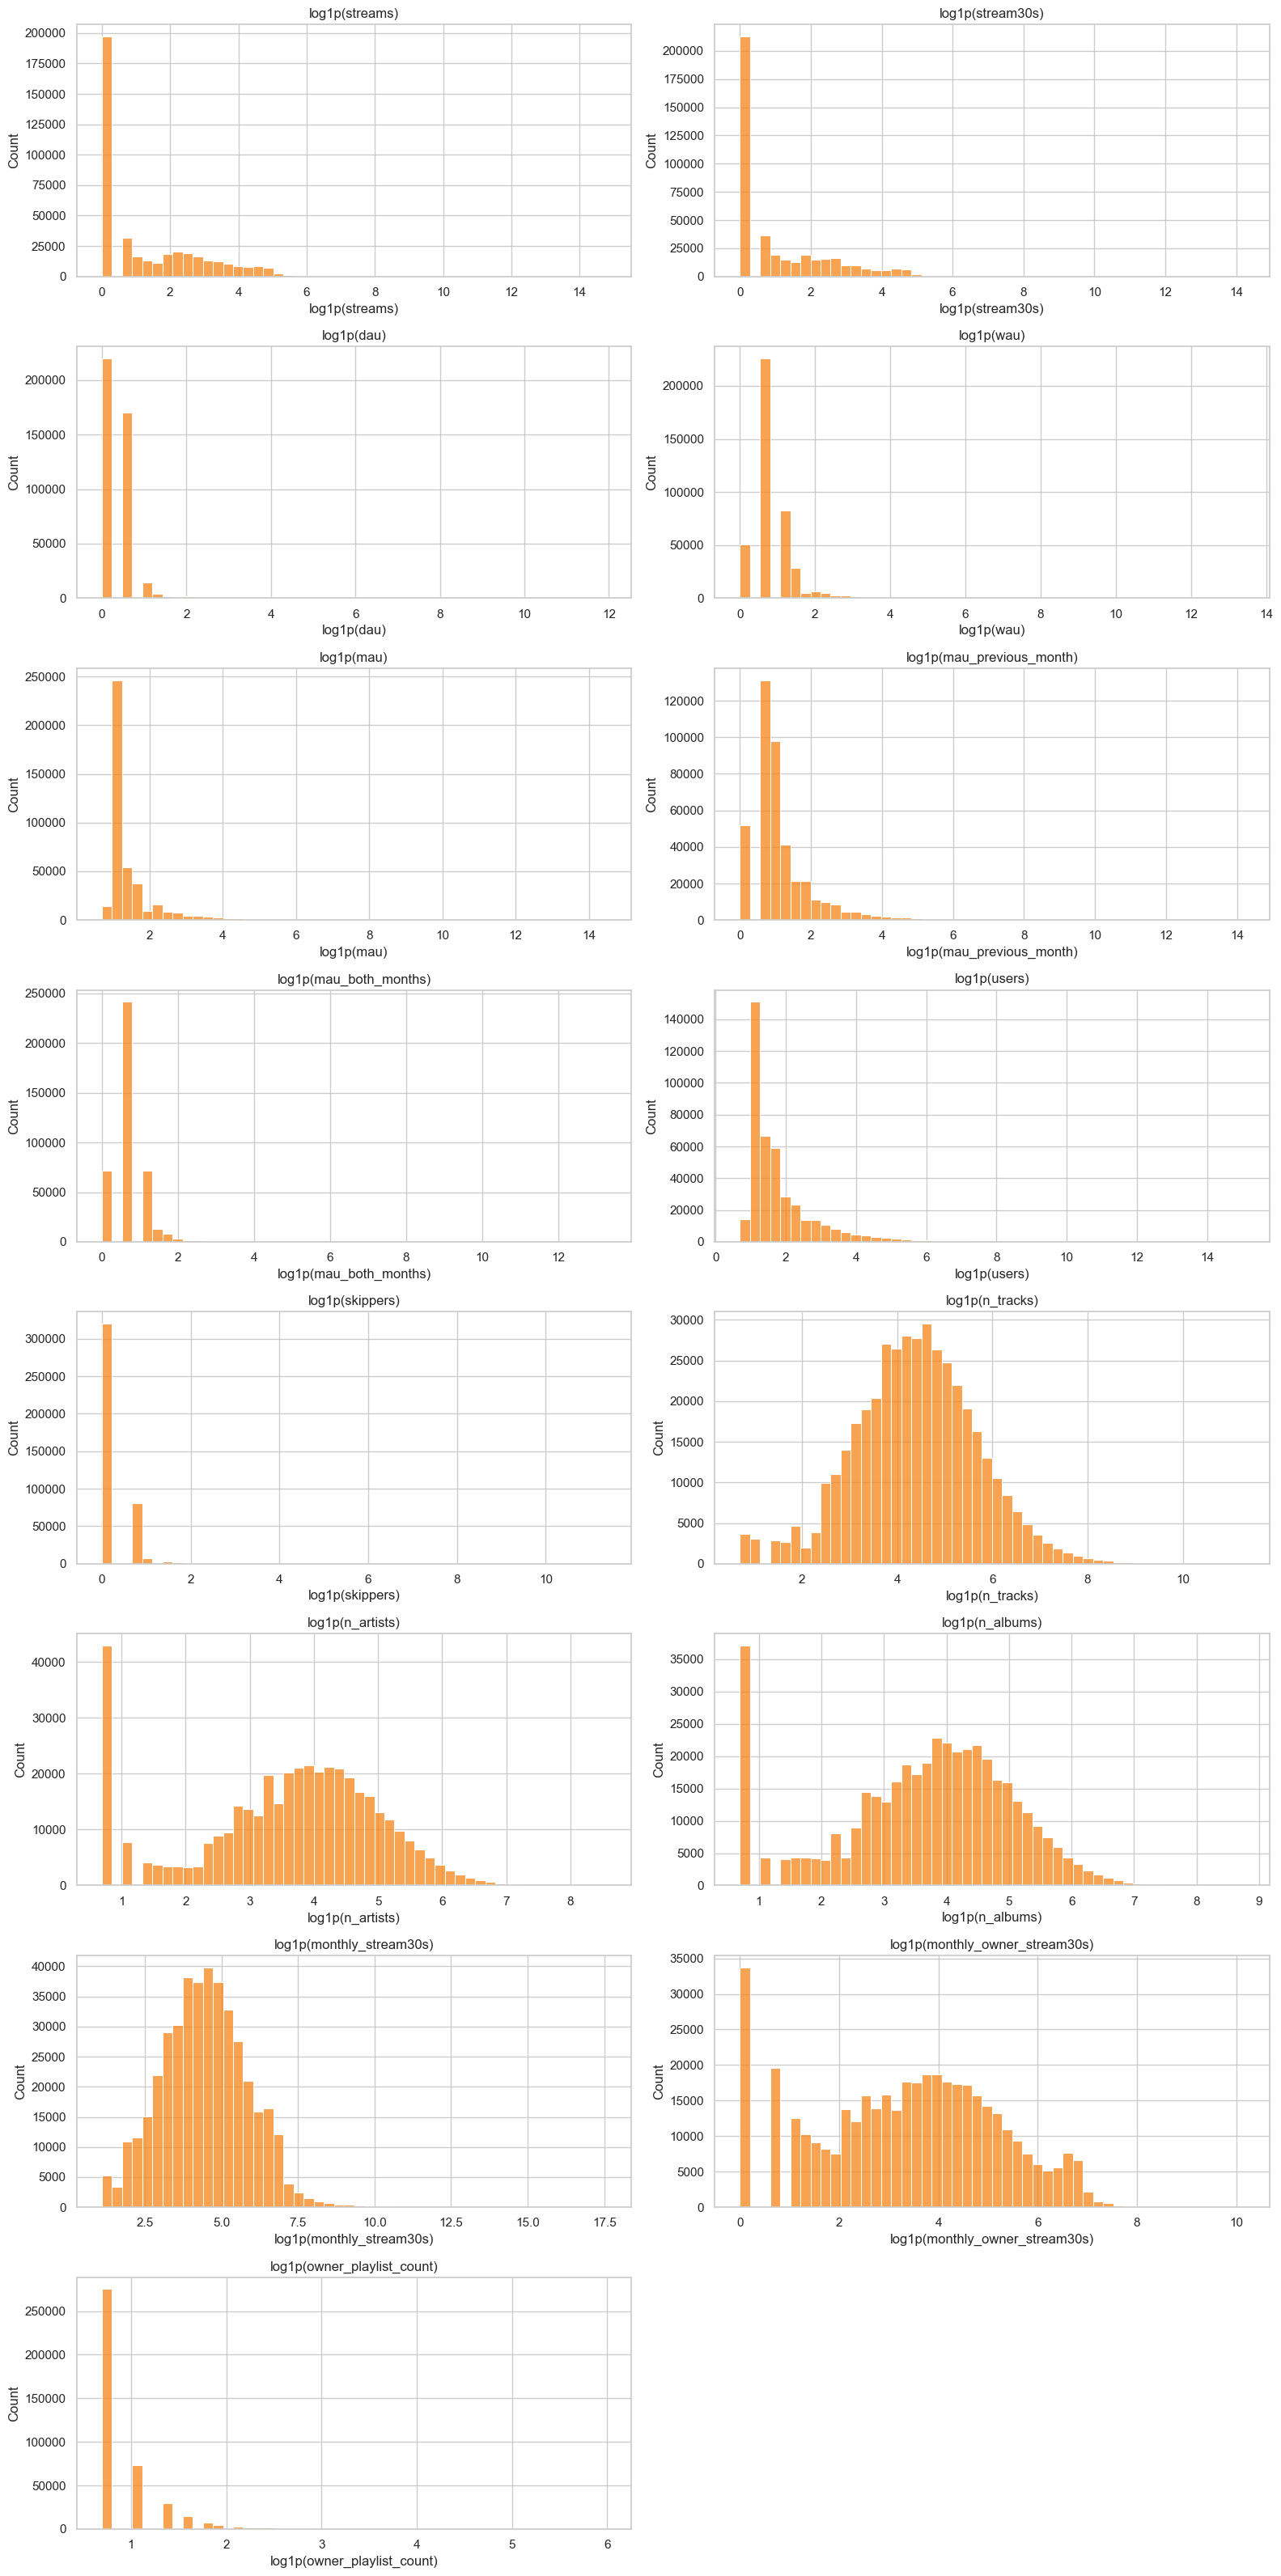

In [77]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    # log1p(x) = log(1 + x), which handles zeros safely.
    sns.histplot(np.log1p(df_clean[col]), bins=50, ax=ax, color='#F58518')
    ax.set_title(f'log1p({col})')
    ax.set_xlabel(f'log1p({col})')

for ax in axes[len(plot_cols):]:
    ax.set_visible(False)

plt.tight_layout()


## 11. Categorical Overview

Start with the most common top-level genres and moods to understand the broad thematic mix of playlists in the sample.


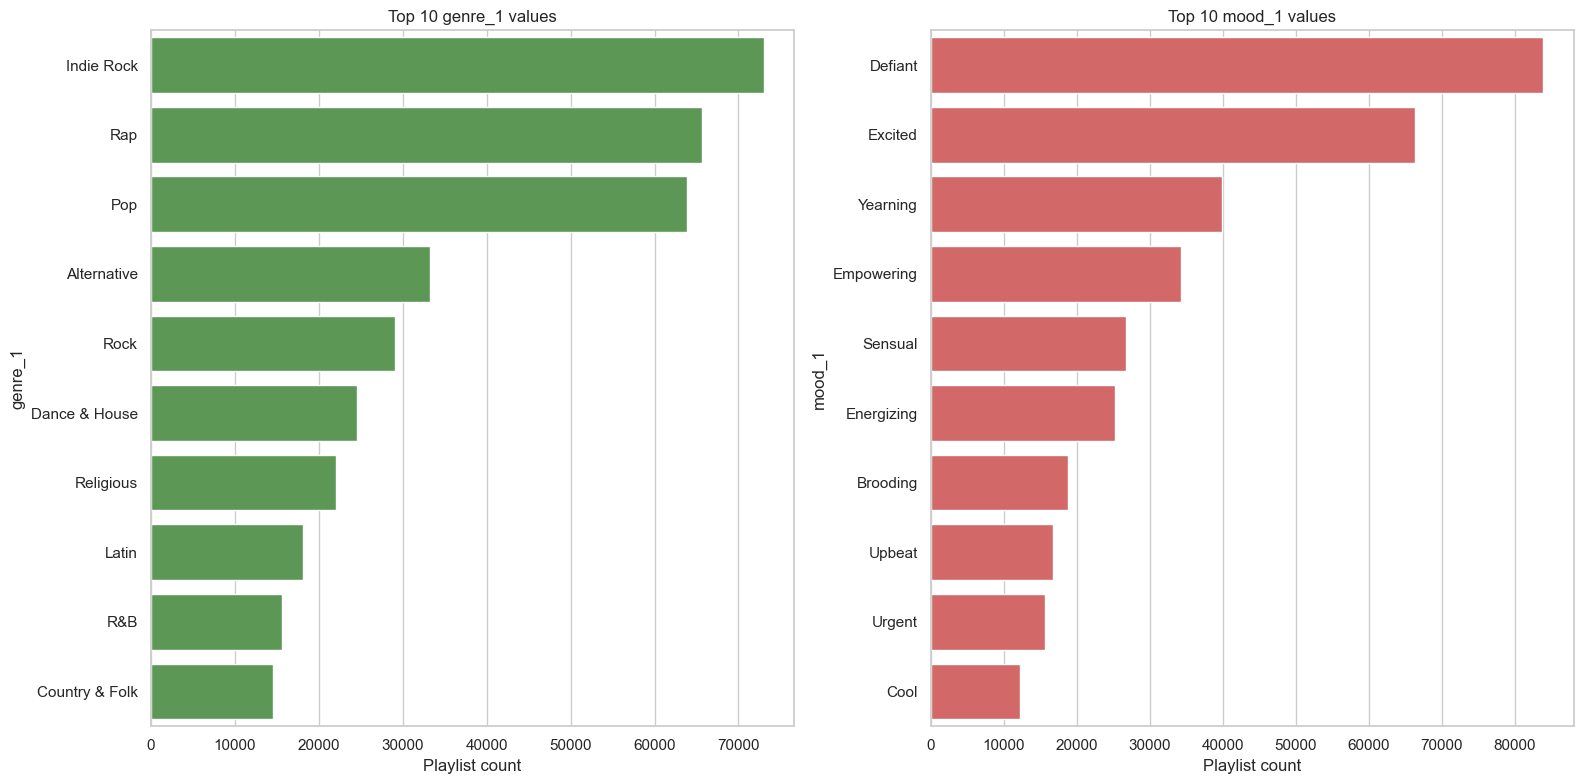

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot the most frequent primary genre values.
top_genres = df_clean['genre_1'].value_counts().head(10).index
sns.countplot(data=df_clean, y='genre_1', order=top_genres, ax=axes[0], color='#54A24B')
axes[0].set_title('Top 10 genre_1 values')
axes[0].set_xlabel('Playlist count')
axes[0].set_ylabel('genre_1')

# Plot the most frequent primary mood values.
top_moods = df_clean['mood_1'].value_counts().head(10).index
sns.countplot(data=df_clean, y='mood_1', order=top_moods, ax=axes[1], color='#E45756')
axes[1].set_title('Top 10 mood_1 values')
axes[1].set_xlabel('Playlist count')
axes[1].set_ylabel('mood_1')

plt.tight_layout()


## 12. Bivariate Relationships

Inspect pairwise relationships between outcome variables and playlist structure variables.

I included both daily `streams`, monthly `monthly_stream30s`, and `mau` as outcomes. The daily stream count can be noisy, so the monthly metric helps show whether the same pattern persists on a more stable horizon.

Because the dataset is large and highly skewed, use:
- a small correlation summary table
- raw-scale hexbin plots capped at the 99th percentile
- log-transformed hexbin plots using `log1p`


In [79]:
# Compare outcome variables with a small set of structural playlist features.
bivariate_targets = ['streams', 'monthly_stream30s', 'mau']
bivariate_features = ['n_tracks', 'n_local_tracks', 'n_artists', 'n_albums']

bivariate_corr_rows = []
for target in bivariate_targets:
    for feature in bivariate_features:
        valid = df_clean[[feature, target]].dropna()
        bivariate_corr_rows.append({
            'target': target,
            'feature': feature,
            'pearson_raw': valid[feature].corr(valid[target]),
            'pearson_log1p': np.corrcoef(np.log1p(valid[feature]), np.log1p(valid[target]))[0, 1],
            'spearman': valid[feature].corr(valid[target], method='spearman')
        })

bivariate_corr_summary = pd.DataFrame(bivariate_corr_rows)
display(bivariate_corr_summary.round(3))


,target,feature,pearson_raw,pearson_log1p,spearman
0,streams,n_tracks,-0.00,0.01,0.08
1,streams,n_local_tracks,-0.00,0.03,0.02
2,streams,n_artists,0.00,-0.01,0.06
3,streams,n_albums,0.00,-0.01,0.06
4,monthly_stream30s,n_tracks,-0.00,0.17,0.23
5,monthly_stream30s,n_local_tracks,-0.00,0.05,0.04
6,monthly_stream30s,n_artists,0.00,0.09,0.16
7,monthly_stream30s,n_albums,0.00,0.10,0.17
8,mau,n_tracks,-0.00,0.08,0.12
9,mau,n_local_tracks,-0.00,-0.02,-0.00


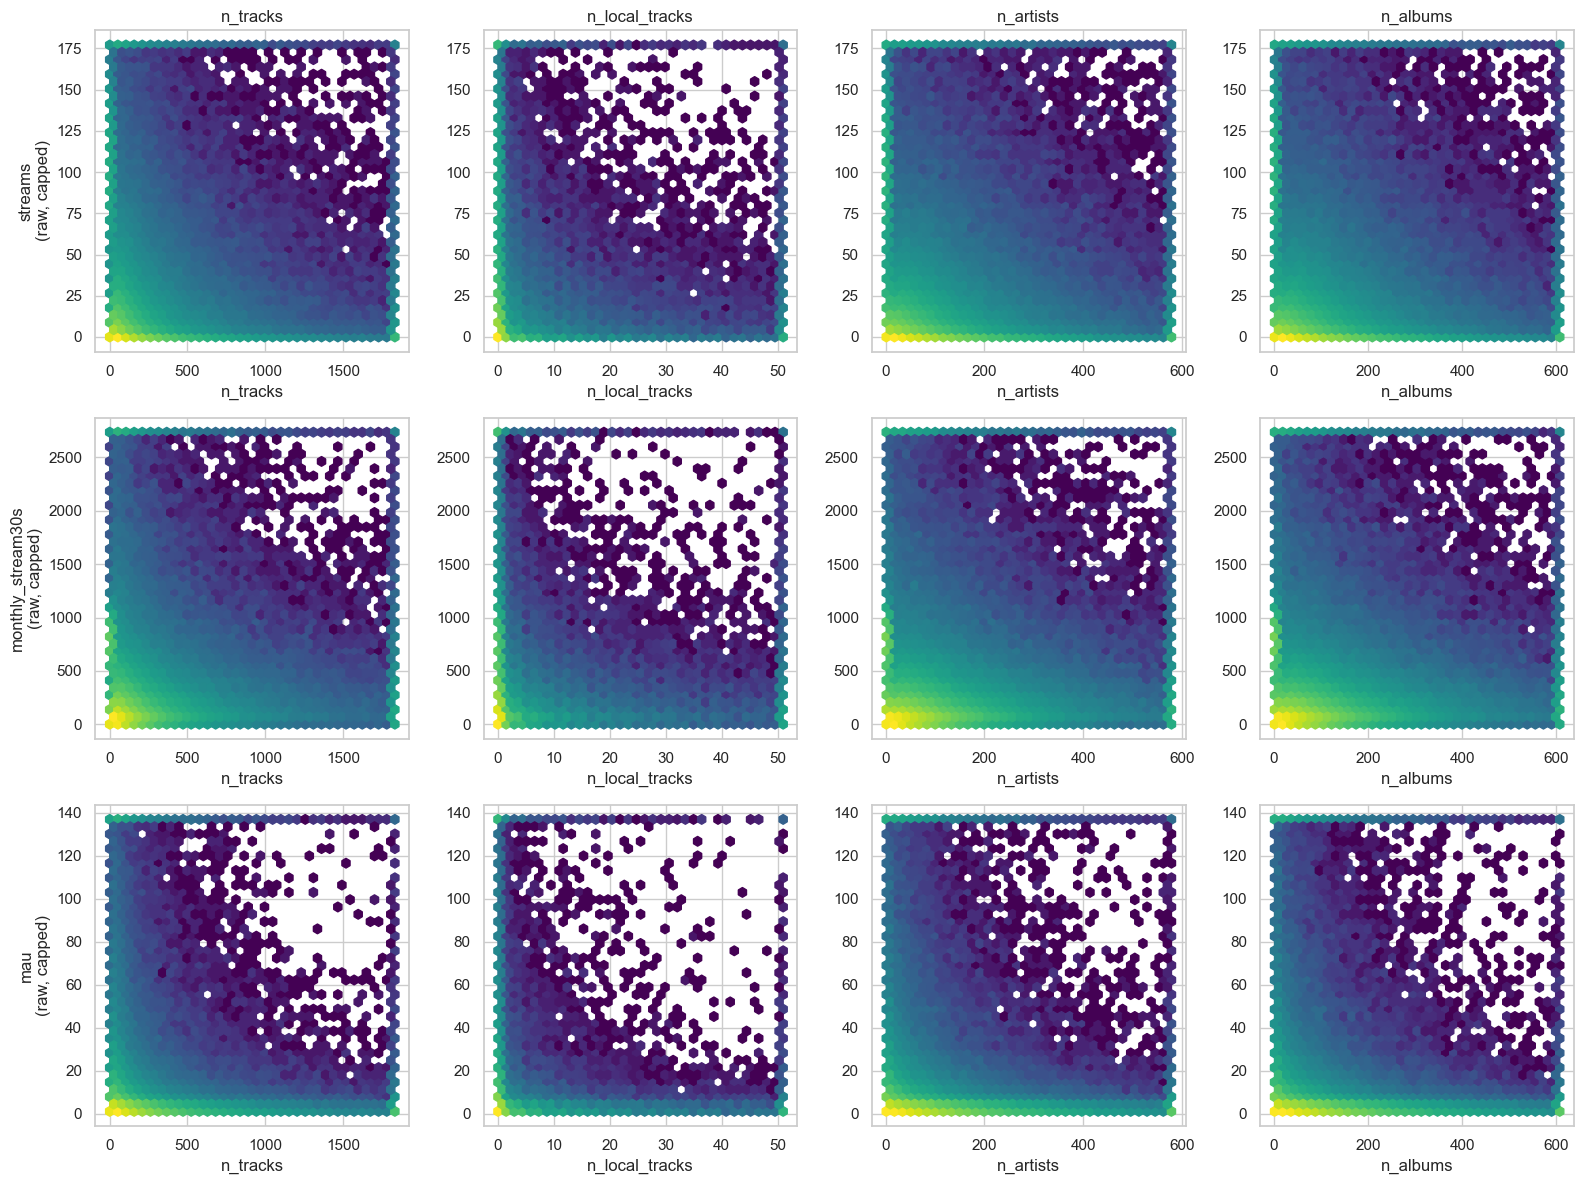

In [80]:
# Raw-scale relationships can be dominated by extreme values, so cap each axis at the 99th percentile.
fig, axes = plt.subplots(len(bivariate_targets), len(bivariate_features), figsize=(4 * len(bivariate_features), 4 * len(bivariate_targets)))

for i, target in enumerate(bivariate_targets):
    for j, feature in enumerate(bivariate_features):
        ax = axes[i, j]
        x_cap = df_clean[feature].quantile(0.99)
        y_cap = df_clean[target].quantile(0.99)

        ax.hexbin(
            df_clean[feature].clip(upper=x_cap),
            df_clean[target].clip(upper=y_cap),
            gridsize=35,
            bins='log',
            mincnt=1,
            cmap='viridis'
        )

        if i == 0:
            ax.set_title(feature)
        if j == 0:
            ax.set_ylabel(f'{target}\n(raw, capped)')
        ax.set_xlabel(feature)

plt.tight_layout()


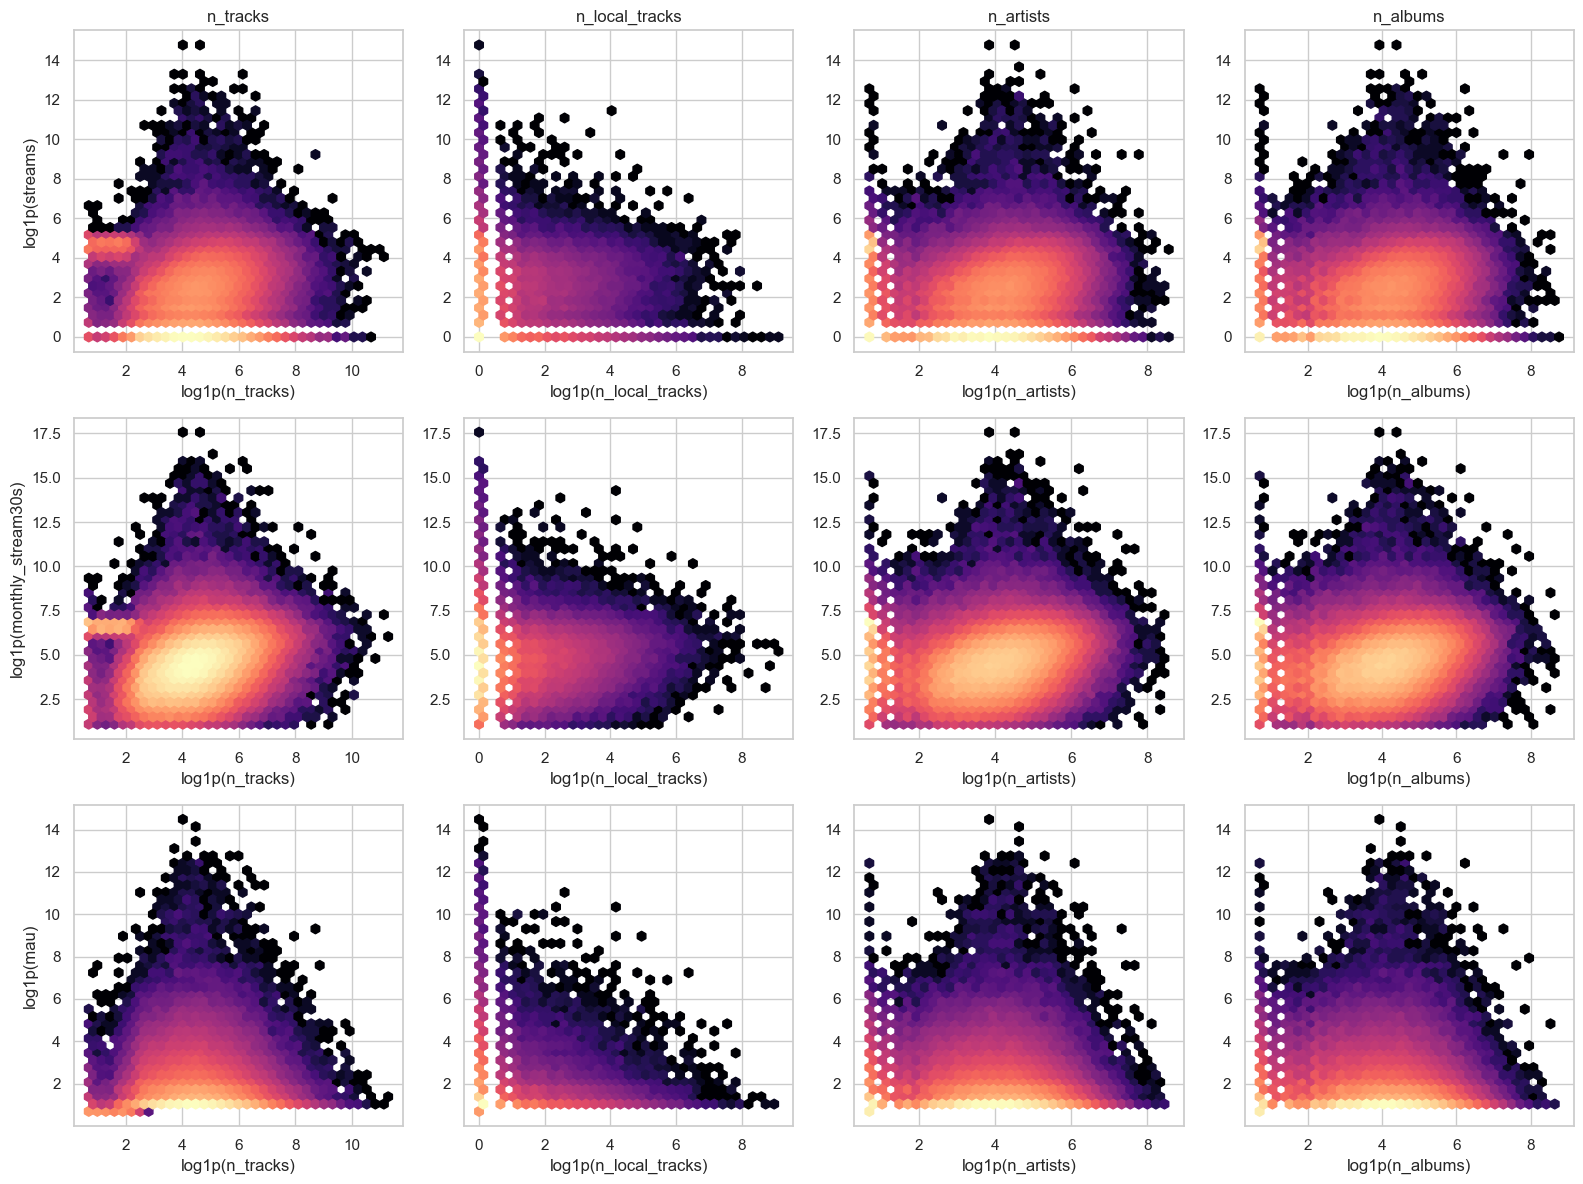

In [81]:
# Log views often make the relationships easier to see because these variables are extremely right-skewed.
fig, axes = plt.subplots(len(bivariate_targets), len(bivariate_features), figsize=(4 * len(bivariate_features), 4 * len(bivariate_targets)))

for i, target in enumerate(bivariate_targets):
    for j, feature in enumerate(bivariate_features):
        ax = axes[i, j]
        ax.hexbin(
            np.log1p(df_clean[feature]),
            np.log1p(df_clean[target]),
            gridsize=35,
            bins='log',
            mincnt=1,
            cmap='magma'
        )

        if i == 0:
            ax.set_title(feature)
        if j == 0:
            ax.set_ylabel(f'log1p({target})')
        ax.set_xlabel(f'log1p({feature})')

plt.tight_layout()
